# Functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def analyze_oos_excess_return(df):
    """
    Analyze and plot the percentage of OOS windows where each
    selection method beats the benchmark.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    analysis_df : pandas.DataFrame
        Detailed results containing counts and percentages.
    """

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            # Count OOS windows with positive excess return
            positive = (group[column] > 0).sum()
            total = group[column].notna().sum()

            pct = 100 * positive / total if total > 0 else float("nan")

            results.append({
                "max_num_components": max_components,
                "method": method,
                "positive_windows": positive,
                "total_windows": total,
                "positive_pct": pct,
            })

    analysis_df = pd.DataFrame(results)

    # ============================================================
    # TABLE
    # ============================================================

    print("\n" + "=" * 80)
    print("OOS EXCESS RETURN — % OF WINDOWS BEATING BENCHMARK")
    print("=" * 80)

    table = (
        analysis_df
        .pivot(
            index="max_num_components",
            columns="method",
            values="positive_pct"
        )
        .round(1)
    )

    print(table)

    # ============================================================
    # PLOT
    # ============================================================

    plt.figure(figsize=(12, 7))

    for method in methods:
        data = analysis_df[analysis_df["method"] == method]

        plt.plot(
            data["max_num_components"],
            data["positive_pct"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=method,
        )

    plt.axhline(
        50,
        linestyle="--",
        linewidth=1,
        label="50% benchmark"
    )

    plt.xlabel("Maximum Number of Components")
    plt.ylabel("OOS Windows Beating Benchmark (%)")
    plt.title(
        "OOS Robustness: Percentage of Windows with Positive Excess Return"
    )

    plt.xticks(sorted(df["max_num_components"].unique()))
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.show()

    return analysis_df

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


def analyze_oos_mean_excess_return(df):
    """
    Analyze and plot the mean OOS excess return across OOS windows
    for each selection method and maximum number of components.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    analysis_mean_df : pandas.DataFrame
        Detailed results containing mean excess returns.
    """

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            # Mean excess return across OOS windows
            mean_excess_return = group[column].mean()

            results.append({
                "max_num_components": max_components,
                "method": method,
                "mean_excess_return": mean_excess_return,
            })

    analysis_mean_df = pd.DataFrame(results)

    # ============================================================
    # TABLE
    # ============================================================

    print("\n" + "=" * 80)
    print("OOS MEAN EXCESS RETURN — AVERAGE ACROSS OOS WINDOWS")
    print("=" * 80)

    table = (
        analysis_mean_df
        .pivot(
            index="max_num_components",
            columns="method",
            values="mean_excess_return"
        )
        .round(4)
    )

    print(table)

    # ============================================================
    # PLOT
    # ============================================================

    plt.figure(figsize=(12, 7))

    for method in methods:

        data = analysis_mean_df[
            analysis_mean_df["method"] == method
        ]

        plt.plot(
            data["max_num_components"],
            data["mean_excess_return"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=method,
        )

    # Zero = benchmark
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="Benchmark (zero excess return)"
    )

    plt.xlabel("Maximum Number of Components")
    plt.ylabel("Mean OOS Excess Return")
    plt.title(
        "OOS Performance: Mean Excess Return Across OOS Windows"
    )

    plt.xticks(
        sorted(df["max_num_components"].unique())
    )

    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.show()

    return analysis_mean_df

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


def analyze_oos_compounded_excess_return(df):
    """
    Analyze and plot compounded OOS excess return across OOS windows
    for each selection method and maximum number of components.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    analysis_compound_df : pandas.DataFrame
        Detailed results containing compounded excess returns.
    """

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            # Remove missing values
            excess_returns = group[column].dropna()

            # Compound excess returns across OOS windows
            compounded_excess_return = (
                (1 + excess_returns).prod() - 1
            )

            results.append({
                "max_num_components": max_components,
                "method": method,
                "compounded_excess_return": compounded_excess_return,
            })

    analysis_compound_df = pd.DataFrame(results)

    # ============================================================
    # TABLE
    # ============================================================

    print("\n" + "=" * 80)
    print("OOS COMPOUNDED EXCESS RETURN")
    print("=" * 80)

    table = (
        analysis_compound_df
        .pivot(
            index="max_num_components",
            columns="method",
            values="compounded_excess_return"
        )
        .mul(100)
        .round(2)
    )

    print(table)

    # ============================================================
    # PLOT
    # ============================================================

    plt.figure(figsize=(12, 7))

    for method in methods:

        data = analysis_compound_df[
            analysis_compound_df["method"] == method
        ]

        plt.plot(
            data["max_num_components"],
            data["compounded_excess_return"] * 100,
            marker="o",
            linewidth=2,
            markersize=6,
            label=method,
        )

    # Zero = benchmark
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="Benchmark (zero excess return)"
    )

    plt.xlabel("Maximum Number of Components")
    plt.ylabel("Compounded OOS Excess Return (%)")
    plt.title(
        "OOS Performance: Compounded Excess Return Across OOS Windows"
    )

    plt.xticks(
        sorted(df["max_num_components"].unique())
    )

    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.show()

    return analysis_compound_df

In [4]:
import pandas as pd
import matplotlib.pyplot as plt


def analyze_oos_sharpe_excess_return(df):
    """
    Analyze and plot the Sharpe ratio of OOS excess returns
    for each selection method and maximum number of components.

    Sharpe ratio is calculated as:

        Mean(excess return) / SD(excess return)

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    analysis_sharpe_df : pandas.DataFrame
        Detailed results containing the Sharpe ratio of
        OOS excess returns.
    """

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            # Remove missing values
            excess_returns = group[column].dropna()

            if len(excess_returns) > 1:

                mean_excess = excess_returns.mean()
                sd_excess = excess_returns.std()

                sharpe_ratio = (
                    mean_excess / sd_excess
                    if sd_excess != 0
                    else float("nan")
                )

            else:
                sharpe_ratio = float("nan")

            results.append({
                "max_num_components": max_components,
                "method": method,
                "sharpe_ratio": sharpe_ratio,
            })

    analysis_sharpe_df = pd.DataFrame(results)

    # ============================================================
    # TABLE
    # ============================================================

    print("\n" + "=" * 80)
    print("OOS SHARPE RATIO — MEAN EXCESS RETURN / SD EXCESS RETURN")
    print("=" * 80)

    table = (
        analysis_sharpe_df
        .pivot(
            index="max_num_components",
            columns="method",
            values="sharpe_ratio"
        )
        .round(3)
    )

    print(table)

    # ============================================================
    # PLOT
    # ============================================================

    plt.figure(figsize=(12, 7))

    for method in methods:

        data = analysis_sharpe_df[
            analysis_sharpe_df["method"] == method
        ]

        plt.plot(
            data["max_num_components"],
            data["sharpe_ratio"],
            marker="o",
            linewidth=2,
            markersize=6,
            label=method,
        )

    # Zero = no risk-adjusted excess return
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="Zero"
    )

    plt.xlabel("Maximum Number of Components")
    plt.ylabel("Sharpe Ratio of OOS Excess Returns")

    plt.title(
        "OOS Risk-Adjusted Performance: Sharpe Ratio of Excess Returns"
    )

    plt.xticks(
        sorted(df["max_num_components"].unique())
    )

    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()

    plt.show()

    return analysis_sharpe_df

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_mpf_rank_heatmap(df):
    """
    Calculate and plot the MPF average-rank heatmap.

    Four OOS performance metrics are used:

        1. % positive OOS windows
        2. Mean excess return
        3. Compounded excess return
        4. Sharpe ratio of excess returns

    Ranking:
        1 = best
        Higher number = worse

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    average_rank : pandas.DataFrame
        Average rank for every method and component count.

    overall_table : pandas.DataFrame
        Overall ranking of component counts.
    """

    # ============================================================
    # 1. DEFINE METHODS
    # ============================================================

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    # ============================================================
    # 2. CALCULATE ALL FOUR PERFORMANCE METRICS
    # ============================================================

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            excess_returns = group[column].dropna()

            if len(excess_returns) == 0:
                continue

            # ----------------------------------------------------
            # 1. Percentage of positive OOS windows
            # ----------------------------------------------------

            positive_pct = (
                (excess_returns > 0).mean() * 100
            )

            # ----------------------------------------------------
            # 2. Mean excess return
            # ----------------------------------------------------

            mean_excess = excess_returns.mean()

            # ----------------------------------------------------
            # 3. Compounded excess return
            # ----------------------------------------------------

            compounded_excess = (
                (1 + excess_returns).prod() - 1
            )

            # ----------------------------------------------------
            # 4. Sharpe ratio of excess returns
            # ----------------------------------------------------

            sd_excess = excess_returns.std()

            if len(excess_returns) > 1 and sd_excess != 0:
                excess_sharpe = mean_excess / sd_excess
            else:
                excess_sharpe = np.nan

            results.append({
                "max_num_components": max_components,
                "method": method,
                "positive_pct": positive_pct,
                "mean_excess": mean_excess,
                "compounded_excess": compounded_excess,
                "excess_sharpe": excess_sharpe,
            })

    metrics_df = pd.DataFrame(results)

    # ============================================================
    # 3. PIVOT THE FOUR METRICS
    # ============================================================

    positive = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="positive_pct"
    )

    mean_excess = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="mean_excess"
    )

    compounded = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="compounded_excess"
    )

    excess_sharpe = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="excess_sharpe"
    )

    # ============================================================
    # 4. RANK EACH METRIC
    #
    # Higher performance = rank 1
    # ============================================================

    rank_positive = positive.rank(
        ascending=False,
        method="average"
    )

    rank_mean = mean_excess.rank(
        ascending=False,
        method="average"
    )

    rank_compounded = compounded.rank(
        ascending=False,
        method="average"
    )

    rank_sharpe = excess_sharpe.rank(
        ascending=False,
        method="average"
    )

    # ============================================================
    # 5. COMBINE THE FOUR RANKS
    # ============================================================

    average_rank = (
        rank_positive
        + rank_mean
        + rank_compounded
        + rank_sharpe
    ) / 4

    # ============================================================
    # 6. OVERALL RANK ACROSS METHODS
    # ============================================================

    overall_rank = average_rank.mean(axis=1)
    overall_rank = overall_rank.sort_index()

    # ============================================================
    # 7. PRINT RANK TABLE
    # ============================================================

    print("\n" + "=" * 90)
    print("MPF — AVERAGE RANK ACROSS FOUR OOS PERFORMANCE METRICS")
    print("=" * 90)

    print(
        average_rank
        .round(2)
        .to_string()
    )

    print("\n" + "=" * 90)
    print("MPF — OVERALL AVERAGE RANK ACROSS ALL FOUR METHODS")
    print("=" * 90)

    print(
        overall_rank
        .sort_values()
        .round(2)
        .to_string()
    )

    # ============================================================
    # 8. CREATE HEATMAP
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(11, 10)
    )

    # Rows    = methods
    # Columns = component counts

    heatmap_data = average_rank.T

    im = ax.imshow(
        heatmap_data.values,
        aspect="auto"
    )

    # ------------------------------------------------------------
    # Axis labels
    # ------------------------------------------------------------

    ax.set_xticks(
        np.arange(len(heatmap_data.columns))
    )

    ax.set_xticklabels(
        heatmap_data.columns
    )

    ax.set_yticks(
        np.arange(len(heatmap_data.index))
    )

    ax.set_yticklabels(
        heatmap_data.index
    )

    ax.set_xlabel(
        "Maximum Number of Components"
    )

    ax.set_ylabel(
        "Selection Method"
    )

    ax.set_title(
        "MPF — Average Rank Across Four OOS Performance Metrics\n"
        "(1 = Best)"
    )

    # ============================================================
    # 9. WRITE RANK VALUE INTO EVERY CELL
    # ============================================================

    for i in range(heatmap_data.shape[0]):

        for j in range(heatmap_data.shape[1]):

            value = heatmap_data.iloc[i, j]

            if not np.isnan(value):

                ax.text(
                    j,
                    i,
                    f"{value:.1f}",
                    ha="center",
                    va="center",
                    fontsize=9
                )

    # ============================================================
    # 10. COLORBAR
    # ============================================================

    cbar = plt.colorbar(
        im,
        ax=ax
    )

    cbar.set_label(
        "Average Rank (lower = better)"
    )

    # ============================================================
    # 11. GRID BETWEEN CELLS
    # ============================================================

    ax.set_xticks(
        np.arange(-0.5, len(heatmap_data.columns), 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, len(heatmap_data.index), 1),
        minor=True
    )

    ax.grid(
        which="minor",
        linestyle="-",
        linewidth=0.5,
        alpha=0.3
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 12. BEST COMPONENT COUNT FOR EACH METHOD
    # ============================================================

    print("\n" + "=" * 90)
    print("BEST COMPONENT COUNT FOR EACH SELECTION METHOD")
    print("=" * 90)

    for method in average_rank.columns:

        best_components = average_rank[method].idxmin()

        best_rank = average_rank.loc[
            best_components,
            method
        ]

        print(
            f"{method:15s}: "
            f"{best_components:2d} components "
            f"(average rank = {best_rank:.2f})"
        )

    # ============================================================
    # 13. OVERALL BEST COMPONENT COUNTS
    # ============================================================

    print("\n" + "=" * 90)
    print("OVERALL BEST COMPONENT COUNTS")
    print("=" * 90)

    overall_table = pd.DataFrame({
        "Average Rank": overall_rank
    })

    overall_table["Overall Rank"] = (
        overall_table["Average Rank"]
        .rank(
            ascending=True,
            method="average"
        )
    )

    print(
        overall_table
        .sort_values("Overall Rank")
        .round(2)
        .to_string()
    )

    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return average_rank, overall_table

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_mpf_oos_cumulative_wealth(
    df,
    candidate_1,
    candidate_2,
    initial_wealth=100.0,
    save_path="mpf_oos_cumulative_wealth.pdf"
):
    """
    Compare cumulative OOS wealth for two MPF candidates
    against the benchmark.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the OOS simulation results.

    candidate_1 : dict
        Candidate specification with:
        - components
        - method
        - return_column
        - label

    candidate_2 : dict
        Candidate specification with:
        - components
        - method
        - return_column
        - label

    initial_wealth : float, default=100.0
        Initial investment.

    save_path : str, default="mpf_oos_cumulative_wealth.pdf"
        Path where the publication-quality PDF is saved.

    Returns
    -------
    results : dict
        Contains the two candidate DataFrames, benchmark,
        final wealth values, and relative outperformance.
    """

    # ============================================================
    # 1. COPY DATA
    # ============================================================

    plot_df = df.copy()

    # ============================================================
    # 2. CONVERT DATES
    # ============================================================

    plot_df["test_start"] = pd.to_datetime(
        plot_df["test_start"],
        format="mixed",
        dayfirst=True
    )

    plot_df["test_end"] = pd.to_datetime(
        plot_df["test_end"],
        format="mixed",
        dayfirst=True
    )

    # ============================================================
    # 3. EXTRACT CANDIDATES
    # ============================================================

    df_1 = (
        plot_df[
            plot_df["max_num_components"]
            == candidate_1["components"]
        ]
        .sort_values("test_start")
        .copy()
    )

    df_2 = (
        plot_df[
            plot_df["max_num_components"]
            == candidate_2["components"]
        ]
        .sort_values("test_start")
        .copy()
    )

    # ============================================================
    # 4. CHECK OOS WINDOWS
    # ============================================================

    print("\nOOS periods — candidate 1:")
    print(
        df_1[
            ["test_start", "test_end"]
        ].to_string(index=False)
    )

    print("\nOOS periods — candidate 2:")
    print(
        df_2[
            ["test_start", "test_end"]
        ].to_string(index=False)
    )

    # ============================================================
    # 5. CALCULATE CUMULATIVE WEALTH
    # ============================================================

    df_1["mpf_wealth"] = (
        initial_wealth
        * (1 + df_1[candidate_1["return_column"]]).cumprod()
    )

    df_2["mpf_wealth"] = (
        initial_wealth
        * (1 + df_2[candidate_2["return_column"]]).cumprod()
    )

    # ============================================================
    # 6. BENCHMARK
    # ============================================================

    df_1["benchmark_wealth"] = (
        initial_wealth
        * (1 + df_1["index_return"]).cumprod()
    )

    # ============================================================
    # 7. FINAL VALUES
    # ============================================================

    final_1 = df_1["mpf_wealth"].iloc[-1]
    final_2 = df_2["mpf_wealth"].iloc[-1]
    final_benchmark = df_1["benchmark_wealth"].iloc[-1]

    # ============================================================
    # 8. TRUE RELATIVE OUTPERFORMANCE
    # ============================================================

    relative_1 = (
        final_1 / final_benchmark - 1
    )

    relative_2 = (
        final_2 / final_benchmark - 1
    )

    # ============================================================
    # 9. PRINT RESULTS
    # ============================================================

    print("\n" + "=" * 80)
    print("OOS CUMULATIVE WEALTH")
    print("=" * 80)

    print(
        f"Initial investment:              "
        f"€{initial_wealth:,.2f}"
    )

    print()

    print(
        f"{candidate_1['label']:<40}"
        f"€{final_1:,.2f}"
    )

    print(
        f"{candidate_2['label']:<40}"
        f"€{final_2:,.2f}"
    )

    print(
        f"{'Benchmark Index':<40}"
        f"€{final_benchmark:,.2f}"
    )

    print("\n" + "=" * 80)
    print("TRUE CUMULATIVE OUTPERFORMANCE VS BENCHMARK")
    print("=" * 80)

    print(
        f"{candidate_1['label']}: "
        f"{relative_1 * 100:+.2f}%"
    )

    print(
        f"{candidate_2['label']}: "
        f"{relative_2 * 100:+.2f}%"
    )

    # ============================================================
    # 10. CREATE FIGURE
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    # ------------------------------------------------------------
    # Candidate 1
    # ------------------------------------------------------------

    ax.plot(
        df_1["test_end"],
        df_1["mpf_wealth"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=candidate_1["label"]
    )

    # ------------------------------------------------------------
    # Candidate 2
    # ------------------------------------------------------------

    ax.plot(
        df_2["test_end"],
        df_2["mpf_wealth"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=candidate_2["label"]
    )

    # ------------------------------------------------------------
    # Benchmark
    # ------------------------------------------------------------

    ax.plot(
        df_1["test_end"],
        df_1["benchmark_wealth"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        linestyle="--",
        label="Benchmark Index"
    )

    # ============================================================
    # 11. INITIAL INVESTMENT LINE
    # ============================================================

    ax.axhline(
        initial_wealth,
        linestyle=":",
        linewidth=1,
        alpha=0.6
    )

    # ============================================================
    # 12. AXIS LABELS
    # ============================================================

    ax.set_xlabel(
        "OOS Test Period"
    )

    ax.set_ylabel(
        "Cumulative Wealth (€)"
    )

    ax.set_title(
        "OOS Cumulative Wealth: MPF vs Benchmark"
    )

    # ============================================================
    # 13. X AXIS
    # ============================================================

    ax.xaxis.set_major_locator(
        mdates.YearLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    # ============================================================
    # 14. GRID
    # ============================================================

    ax.grid(
        True,
        alpha=0.25
    )

    # ============================================================
    # 15. LEGEND
    # ============================================================

    ax.legend(
        loc="best",
        frameon=True
    )

    # ============================================================
    # 16. FINAL VALUE LABELS
    # ============================================================

    ax.annotate(
        f"€{final_1:.1f}",
        xy=(
            df_1["test_end"].iloc[-1],
            final_1
        ),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

    ax.annotate(
        f"€{final_2:.1f}",
        xy=(
            df_2["test_end"].iloc[-1],
            final_2
        ),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

    ax.annotate(
        f"€{final_benchmark:.1f}",
        xy=(
            df_1["test_end"].iloc[-1],
            final_benchmark
        ),
        xytext=(10, 0),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

    # ============================================================
    # 17. LAYOUT
    # ============================================================

    plt.tight_layout()

    # ============================================================
    # 18. SAVE PDF
    # ============================================================

    if save_path is not None:
        plt.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight"
        )

    plt.show()

    # ============================================================
    # 19. RETURN RESULTS
    # ============================================================

    return {
        "candidate_1_df": df_1,
        "candidate_2_df": df_2,
        "final_wealth_1": final_1,
        "final_wealth_2": final_2,
        "final_benchmark": final_benchmark,
        "relative_outperformance_1": relative_1,
        "relative_outperformance_2": relative_2,
    }

In [7]:
from pathlib import Path
import pandas as pd
import re
import json
from datetime import datetime


def summarize_mpf_results(results_dir="results"):
    """
    Create a summary table of all MPF walk-forward experiments.

    Each experiment is identified primarily by its JSON metadata file.

    Status:
        RUNNING   -> JSON exists but result CSV does not yet exist
        COMPLETED -> JSON and result CSV both exist

    Run duration:
        COMPLETED -> CSV modification time - JSON start time
        RUNNING   -> current time - JSON start time

    Parameters
    ----------
    results_dir : str or Path
        Directory containing MPF result files.

    Returns
    -------
    pd.DataFrame
        Summary table, one row per experiment/run.
    """

    results_dir = Path(results_dir)

    # ------------------------------------------------------------------
    # Find JSON files.
    #
    # JSON is the primary source because it is created when the
    # experiment starts.
    # ------------------------------------------------------------------
    json_files = sorted(
        results_dir.glob("wf_*.json"),
        key=lambda x: x.stat().st_mtime,
        reverse=True
    )

    rows = []

    # ------------------------------------------------------------------
    # Filename pattern
    # ------------------------------------------------------------------
    pattern = re.compile(
        r"wf_(?P<strategy>.+?)"
        r"_cal(?P<cal>\d+)"
        r"_move(?P<move>\d+)"
        r"_test(?P<test>\d+)"
        r"_ncomp(?P<ncomp_start>\d+)-(?P<ncomp_end>\d+)"
        r"_(?P<timestamp>\d{8}_\d{6})_"
        r"(?P<run_id>[a-f0-9]+)\.json"
    )

    # ------------------------------------------------------------------
    # Current time
    # ------------------------------------------------------------------
    now = pd.Timestamp.now()

    # ------------------------------------------------------------------
    # Process every JSON file
    # ------------------------------------------------------------------
    for json_file in json_files:

        match = pattern.match(json_file.name)

        if not match:
            continue

        info = match.groupdict()

        # ------------------------------------------------------------------
        # Component range
        # ------------------------------------------------------------------
        ncomp_start = int(info["ncomp_start"])
        ncomp_end = int(info["ncomp_end"])

        if ncomp_start == ncomp_end:
            components = str(ncomp_start)
        else:
            components = f"{ncomp_start}–{ncomp_end}"

        # ------------------------------------------------------------------
        # Read JSON metadata
        # ------------------------------------------------------------------
        metadata = {}

        try:
            with open(json_file, "r") as f:
                metadata = json.load(f)

        except Exception as e:

            print(
                f"Warning: could not read "
                f"{json_file.name}: {e}"
            )

        # ------------------------------------------------------------------
        # Start time
        #
        # Prefer timestamp_utc from JSON.
        # Fall back to filename timestamp.
        # ------------------------------------------------------------------
        try:

            start_time = pd.to_datetime(
                metadata.get(
                    "timestamp_utc",
                    info["timestamp"]
                ),
                format="%Y%m%d_%H%M%S"
            )

        except Exception:

            start_time = pd.to_datetime(
                info["timestamp"],
                format="%Y%m%d_%H%M%S"
            )

        # ------------------------------------------------------------------
        # Result CSV
        # ------------------------------------------------------------------
        stem = json_file.stem

        result_file = results_dir / f"{stem}.csv"
        metrics_file = results_dir / f"{stem}_metrics.csv"
        ranking_file = results_dir / f"{stem}_ranking.csv"

        # ------------------------------------------------------------------
        # Determine status and end time
        # ------------------------------------------------------------------
        if result_file.exists():

            status = "COMPLETED"

            # CSV modification time = completion time
            end_time = pd.to_datetime(
                result_file.stat().st_mtime,
                unit="s"
            )

        else:

            status = "RUNNING"

            # No CSV yet -> use current time
            end_time = now

        # ------------------------------------------------------------------
        # Duration
        # ------------------------------------------------------------------
        duration = end_time - start_time

        duration_seconds = int(
            duration.total_seconds()
        )

        if duration_seconds >= 0:

            hours, remainder = divmod(
                duration_seconds,
                3600
            )

            minutes, seconds = divmod(
                remainder,
                60
            )

            duration_str = (
                f"{hours:02d}:"
                f"{minutes:02d}:"
                f"{seconds:02d}"
            )

        else:

            duration_str = "ERROR"

        # ------------------------------------------------------------------
        # Read result CSV if available
        # ------------------------------------------------------------------
        result_df = pd.DataFrame()

        if result_file.exists():

            try:

                result_df = pd.read_csv(
                    result_file
                )

                n_rows = len(result_df)

            except Exception as e:

                print(
                    f"Warning: could not read "
                    f"{result_file.name}: {e}"
                )

                n_rows = None

        else:

            n_rows = None

        # ------------------------------------------------------------------
        # Determine OOS end date
        # ------------------------------------------------------------------
        end_date = None

        if not result_df.empty:

            for column in [
                "test_end",
                "TEST_END",
                "end_date",
                "END_DATE"
            ]:

                if column in result_df.columns:

                    dates = pd.to_datetime(
                        result_df[column],
                        errors="coerce"
                    )

                    if dates.notna().any():

                        end_date = dates.max().date()

                    break

        # ------------------------------------------------------------------
        # Add row
        # ------------------------------------------------------------------
        rows.append({

            # --------------------------------------------------------------
            # Run status
            # --------------------------------------------------------------
            "status": status,

            "run_date": start_time.date(),

            "start_time": start_time.strftime(
                "%H:%M:%S"
            ),

            "end_time": (
                end_time.strftime("%H:%M:%S")
                if status == "COMPLETED"
                else None
            ),

            "duration": duration_str,

            "run_id": info["run_id"],

            # --------------------------------------------------------------
            # Experiment
            # --------------------------------------------------------------
            "strategy": metadata.get(
                "STRATEGY",
                info["strategy"]
            ),

            "start_date": metadata.get(
                "START_DATE"
            ),

            "end_date": end_date,

            # --------------------------------------------------------------
            # Walk-forward parameters
            # --------------------------------------------------------------
            "calibration": metadata.get(
                "CALIBRATION_WINDOW",
                int(info["cal"])
            ),

            "move": metadata.get(
                "MOVING_PARAM",
                int(info["move"])
            ),

            "test": metadata.get(
                "TEST_SPAN",
                int(info["test"])
            ),

            "components": components,

            # --------------------------------------------------------------
            # Simulations
            # --------------------------------------------------------------
            "stage1_simulations": metadata.get(
                "N_SIMULATIONS_STAGE1"
            ),

            "stage2_simulations": metadata.get(
                "N_SIMULATIONS_STAGE2"
            ),

            # --------------------------------------------------------------
            # Optimization
            # --------------------------------------------------------------
            "threshold_step": metadata.get(
                "THRESHOLD_STEP"
            ),

            "random_state": metadata.get(
                "RANDOM_STATE"
            ),

            # --------------------------------------------------------------
            # Portfolio parameters
            # --------------------------------------------------------------
            "initial_capital": metadata.get(
                "INITIAL_CAPITAL"
            ),

            "cost_per_trade": metadata.get(
                "ABS_COST_FOR_A_TRADE"
            ),

            "percent_cost": metadata.get(
                "PERCENT_COST_FOR_A_TRADE"
            ),

            "max_investment_pct": metadata.get(
                "MAX_INVESTMENT_SIZE_IN_PERCENT"
            ),

            "min_cash_pct": metadata.get(
                "MIN_CASH_IN_PERCENT"
            ),

            # --------------------------------------------------------------
            # Computing
            # --------------------------------------------------------------
            "max_workers": metadata.get(
                "MAX_WORKERS"
            ),

            # --------------------------------------------------------------
            # Output information
            # --------------------------------------------------------------
            "result_rows": n_rows,

            "metrics": metrics_file.exists(),

            "ranking": ranking_file.exists(),

            "json": json_file.exists(),

            "result_file": (
                result_file.name
                if result_file.exists()
                else None
            ),
        })

    # ----------------------------------------------------------------------
    # Create DataFrame
    # ----------------------------------------------------------------------
    summary = pd.DataFrame(rows)

    if summary.empty:

        print("No MPF experiment JSON files found.")

        return summary

    # ----------------------------------------------------------------------
    # Convert dates
    # ----------------------------------------------------------------------
    summary["start_date"] = pd.to_datetime(
        summary["start_date"],
        errors="coerce"
    ).dt.date

    summary["end_date"] = pd.to_datetime(
        summary["end_date"],
        errors="coerce"
    ).dt.date

    # ----------------------------------------------------------------------
    # Sort newest runs first
    # ----------------------------------------------------------------------
    summary = summary.sort_values(
        ["run_date", "start_time"],
        ascending=False
    ).reset_index(drop=True)

    return summary

# Data

In [8]:
import pandas as pd

df = pd.read_csv("../results/wf_mean_reversion_cal6_move12_test12_ncomp5-20_20260903_140908_8d95d5eb78df.csv")
df.columns

Index(['max_num_components', 'calibration_start', 'calibration_end',
       'test_start', 'test_end', 'stage1_robust_buy_thr',
       'stage1_robust_sell_thr', 'stage1_top10_buy_std',
       'stage1_top10_sell_std', 'stage2_buy_min', 'stage2_buy_max',
       'stage2_sell_min', 'stage2_sell_max', 'sharpe_buy_thr',
       'sharpe_sell_thr', 'sharpe_calibration', 'sharpe_calibration_return',
       'sharpe_oos_return', 'sharpe_excess_return', 'calmar_buy_thr',
       'calmar_sell_thr', 'calmar_calibration', 'calmar_calibration_return',
       'calmar_oos_return', 'calmar_excess_return', 'return_risk_buy_thr',
       'return_risk_sell_thr', 'return_risk_calibration',
       'return_risk_calibration_return', 'return_risk_oos_return',
       'return_risk_excess_return', 'robust_buy_thr', 'robust_sell_thr',
       'robust_calibration_sharpe', 'robust_calibration_return',
       'robust_calibration_calmar', 'robust_calibration_return_risk',
       'robust_oos_return', 'robust_excess_return', '

In [11]:
df_selected = df.loc[:, df.columns.str.contains(
    r'_buy_thr|_sell_thr|max_num_components',
    case=False,
    regex=True
)]

In [13]:
summary = summarize_mpf_results("../results")

print("\n" + "=" * 160)
print("MPF — EXPERIMENT SUMMARY")
print("=" * 160)

print(
    summary[
        [
            "status",
            "run_date",
            "start_time",
            "end_time",
            "duration",
            "strategy",
            "start_date",
            "end_date",
            "calibration",
            "move",
            "test",
            "components",
            "stage1_simulations",
            "stage2_simulations",
            "metrics",
            "ranking",
        ]
    ].to_string(index=False)
)

print("=" * 160)


MPF — EXPERIMENT SUMMARY
   status   run_date start_time end_time duration       strategy start_date   end_date  calibration  move  test components  stage1_simulations  stage2_simulations  metrics  ranking
  RUNNING 2026-09-04   09:53:00     None 04:43:16 mean_reversion 2009-01-01        NaT            6    12    12       5–20                 500                 250    False    False
COMPLETED 2026-09-03   14:09:08 08:02:49 17:53:41 mean_reversion 2009-01-01 2023-12-29            6    12    12       5–20                 500                 100    False    False


# Research

## Mean Reversion

### Train on 500/500 CLASICAL RANKING

In [ ]:
import pandas as pd

# Train 500/500 results
#df = pd.read_csv("../results/wf_mean_reversion_cal6_move12_test12_ncomp2-20_20260826_134734_ccddf69dfe95.csv")


OOS EXCESS RETURN — % OF WINDOWS BEATING BENCHMARK
method              Calmar  Return/Risk  Robust  Sharpe
max_num_components                                     
5                     44.4         44.4    22.2    44.4
6                     55.6         66.7    44.4    66.7
7                     22.2         22.2    44.4    22.2
8                     33.3         55.6    44.4    55.6
9                     44.4         44.4    55.6    55.6
10                    33.3         33.3    66.7    33.3
11                    33.3         33.3    33.3    33.3
12                    66.7         66.7    33.3    66.7
13                    33.3         33.3    44.4    33.3
14                    55.6         44.4    22.2    44.4
15                    66.7         55.6    55.6    55.6
16                    44.4         44.4    44.4    44.4
17                    44.4         44.4    11.1    44.4
18                    66.7         66.7    44.4    77.8
19                    11.1         22.2    44.4    2

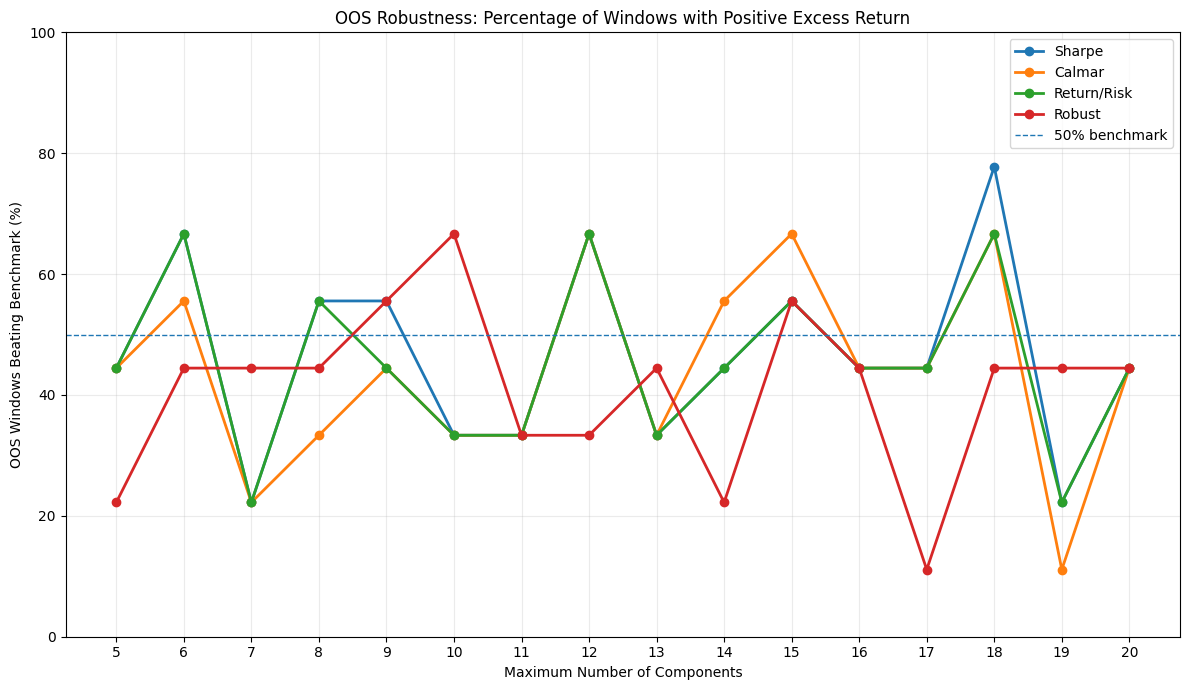

In [30]:
analysis_1_df = analyze_oos_excess_return(df)

In [ ]:
analysis_2_df = analyze_oos_mean_excess_return(df)

In [ ]:
analysis_3_df = analyze_oos_compounded_excess_return(df)

In [ ]:
analysis_4_df = analyze_oos_sharpe_excess_return(df)


MPF — AVERAGE RANK ACROSS FOUR OOS PERFORMANCE METRICS
method              Calmar  Return/Risk  Robust  Sharpe
max_num_components                                     
5                     4.50        10.88   13.62    3.50
6                     5.12         3.00   12.88    4.88
7                    15.25        15.62    3.38   15.62
8                     7.88         3.88    7.62    6.25
9                     3.50         5.88    3.62    4.00
10                   13.12        10.00    1.00   10.75
11                   14.12        14.25   12.62   14.25
12                    7.75         6.50   11.38    7.38
13                   11.38        11.25    5.88   12.50
14                    5.38        12.38    8.88   12.25
15                    1.25         1.88    5.38    2.25
16                    9.00         7.12    8.62    8.25
17                    8.00         3.62   15.00    5.50
18                    3.75         5.25   10.12    3.75
19                   15.00        13.88    4.12 

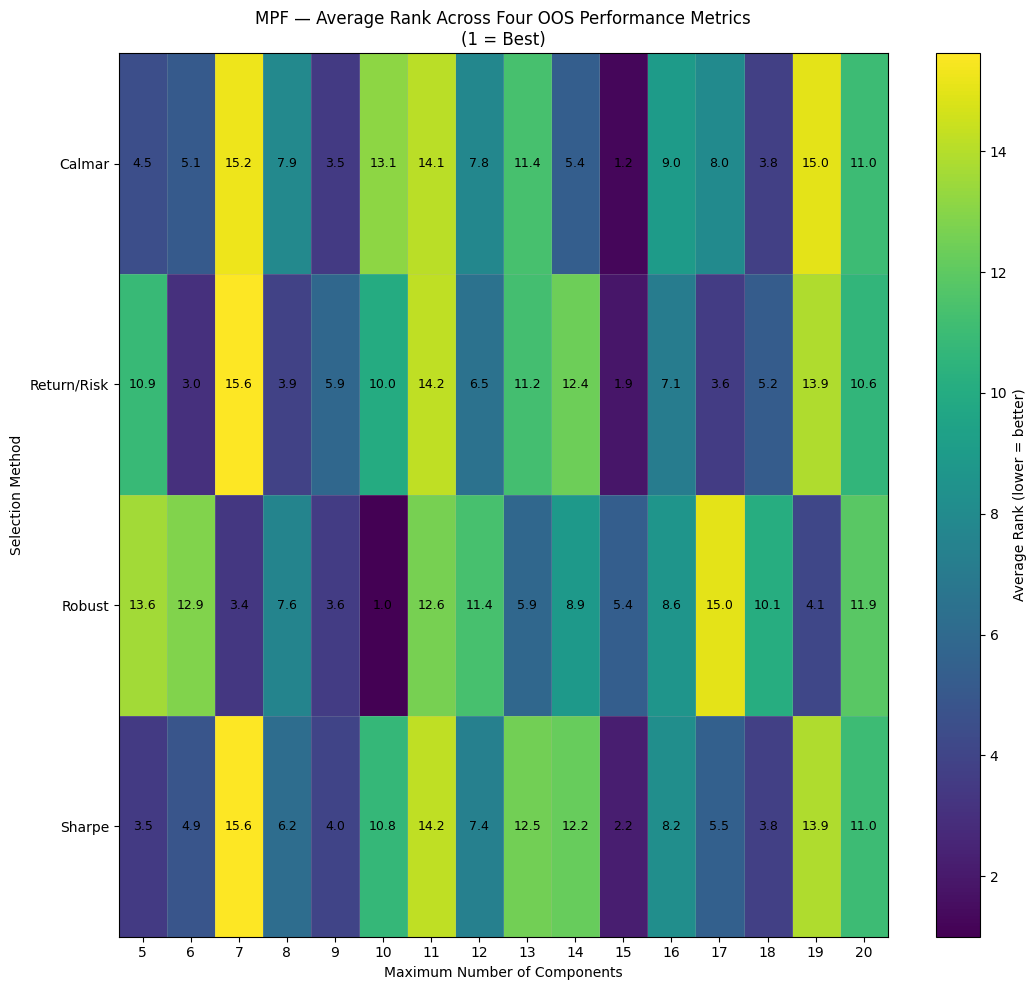


BEST COMPONENT COUNT FOR EACH SELECTION METHOD
Calmar         : 15 components (average rank = 1.25)
Return/Risk    : 15 components (average rank = 1.88)
Robust         : 10 components (average rank = 1.00)
Sharpe         : 15 components (average rank = 2.25)

OVERALL BEST COMPONENT COUNTS
                    Average Rank  Overall Rank
max_num_components                            
15                          2.69           1.0
9                           4.25           2.0
18                          5.72           3.0
8                           6.41           4.0
6                           6.47           5.0
17                          8.03           6.0
5                           8.12           7.0
12                          8.25           8.5
16                          8.25           8.5
10                          8.72          10.0
14                          9.72          11.0
13                         10.25          12.0
20                         11.12          13.0
19  

In [31]:
average_rank, overall_table = plot_mpf_rank_heatmap(df)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_mpf_rank_2d(df):
    """
    Calculate MPF average ranks across four OOS performance metrics
    and plot the result as a 2D publication-style scatter plot.

    X-axis:
        Average rank across the four OOS metrics.
        Lower = better.

    Y-axis:
        Maximum number of components.

    Markers:
        Robust       = black filled circle
        Sharpe       = gray square
        Calmar       = dark gray triangle
        Return/Risk  = light gray diamond

    The plot is designed for black-and-white publication/PDF output.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing:
        - max_num_components
        - sharpe_excess_return
        - calmar_excess_return
        - return_risk_excess_return
        - robust_excess_return

    Returns
    -------
    average_rank : pandas.DataFrame
        Average rank for every method and component count.

    overall_table : pandas.DataFrame
        Overall ranking of component counts.
    """

    # ============================================================
    # 1. DEFINE METHODS
    # ============================================================

    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    # ============================================================
    # 2. CALCULATE FOUR PERFORMANCE METRICS
    # ============================================================

    results = []

    for max_components, group in df.groupby("max_num_components"):

        for method, column in methods.items():

            excess_returns = group[column].dropna()

            if len(excess_returns) == 0:
                continue

            # ----------------------------------------------------
            # 1. Percentage of positive OOS windows
            # ----------------------------------------------------

            positive_pct = (
                (excess_returns > 0).mean() * 100
            )

            # ----------------------------------------------------
            # 2. Mean excess return
            # ----------------------------------------------------

            mean_excess = excess_returns.mean()

            # ----------------------------------------------------
            # 3. Compounded excess return
            # ----------------------------------------------------

            compounded_excess = (
                (1 + excess_returns).prod() - 1
            )

            # ----------------------------------------------------
            # 4. Sharpe ratio of excess returns
            # ----------------------------------------------------

            sd_excess = excess_returns.std()

            if len(excess_returns) > 1 and sd_excess != 0:
                excess_sharpe = mean_excess / sd_excess
            else:
                excess_sharpe = np.nan

            results.append({
                "max_num_components": max_components,
                "method": method,
                "positive_pct": positive_pct,
                "mean_excess": mean_excess,
                "compounded_excess": compounded_excess,
                "excess_sharpe": excess_sharpe,
            })

    metrics_df = pd.DataFrame(results)

    # ============================================================
    # 3. PIVOT METRICS
    # ============================================================

    positive = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="positive_pct"
    )

    mean_excess = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="mean_excess"
    )

    compounded = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="compounded_excess"
    )

    excess_sharpe = metrics_df.pivot(
        index="max_num_components",
        columns="method",
        values="excess_sharpe"
    )

    # ============================================================
    # 4. RANK EACH METRIC
    #
    # Higher performance = rank 1
    # ============================================================

    rank_positive = positive.rank(
        ascending=False,
        method="average"
    )

    rank_mean = mean_excess.rank(
        ascending=False,
        method="average"
    )

    rank_compounded = compounded.rank(
        ascending=False,
        method="average"
    )

    rank_sharpe = excess_sharpe.rank(
        ascending=False,
        method="average"
    )

    # ============================================================
    # 5. COMBINE THE FOUR RANKS
    # ============================================================

    average_rank = (
        rank_positive
        + rank_mean
        + rank_compounded
        + rank_sharpe
    ) / 4

    average_rank = average_rank.sort_index()

    # ============================================================
    # 6. PRINT RANK TABLE
    # ============================================================

    print("\n" + "=" * 90)
    print("MPF — AVERAGE RANK ACROSS FOUR OOS PERFORMANCE METRICS")
    print("=" * 90)

    print(
        average_rank
        .round(2)
        .to_string()
    )

    # ============================================================
    # 7. OVERALL RANK ACROSS METHODS
    # ============================================================

    overall_rank = average_rank.mean(axis=1)

    print("\n" + "=" * 90)
    print("MPF — OVERALL AVERAGE RANK ACROSS ALL FOUR METHODS")
    print("=" * 90)

    print(
        overall_rank
        .sort_values()
        .round(2)
        .to_string()
    )

    # ============================================================
    # 8. PREPARE LONG-FORM DATA FOR PLOT
    # ============================================================

    plot_df = (
        average_rank
        .reset_index()
        .melt(
            id_vars="max_num_components",
            var_name="method",
            value_name="average_rank"
        )
        .dropna()
    )

    # ============================================================
    # 9. PUBLICATION-STYLE SETTINGS
    # ============================================================

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
    })

    # ============================================================
    # 10. CREATE 2D SCATTER PLOT
    # ============================================================

    fig, ax = plt.subplots(
        figsize=(7.0, 5.2)
    )

    # ------------------------------------------------------------
    # Marker definitions
    #
    # Robust is deliberately black.
    # Other methods use grayscale + different symbols.
    # ------------------------------------------------------------

    styles = {
        "Sharpe": {
            "marker": "s",
            "facecolor": "0.75",
            "edgecolor": "black",
            "size": 55,
        },

        "Calmar": {
            "marker": "^",
            "facecolor": "0.50",
            "edgecolor": "black",
            "size": 65,
        },

        "Return/Risk": {
            "marker": "D",
            "facecolor": "0.85",
            "edgecolor": "black",
            "size": 55,
        },

        "Robust": {
            "marker": "o",
            "facecolor": "black",
            "edgecolor": "black",
            "size": 55,
        },
    }

    # ============================================================
    # 11. PLOT EACH METHOD
    # ============================================================

    for method in methods.keys():

        subset = plot_df[
            plot_df["method"] == method
        ]

        style = styles[method]

        ax.scatter(
            subset["average_rank"],
            subset["max_num_components"],
            marker=style["marker"],
            s=style["size"],
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.8,
            alpha=1.0,
            label=method,
            zorder=3,
        )

    # ============================================================
    # 12. AXIS LABELS
    # ============================================================

    ax.set_xlabel(
        "Average Rank Across Four OOS Metrics"
    )

    ax.set_ylabel(
        "Maximum Number of Components"
    )

    ax.set_title(
        "MPF — OOS Performance Rank"
    )

    # ============================================================
    # 13. Y-AXIS
    # ============================================================

    components = sorted(
        plot_df["max_num_components"].unique()
    )

    ax.set_yticks(components)

    # ============================================================
    # 14. GRID
    # ============================================================

    ax.grid(
        axis="x",
        linestyle="--",
        linewidth=0.5,
        alpha=0.35,
        zorder=0
    )

    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.4,
        alpha=0.25,
        zorder=0
    )

    # ============================================================
    # 15. AXIS LIMITS
    # ============================================================

    xmin = plot_df["average_rank"].min()
    xmax = plot_df["average_rank"].max()

    padding = max(
        0.5,
        (xmax - xmin) * 0.08
    )

    ax.set_xlim(
        xmin - padding,
        xmax + padding
    )

    # ============================================================
    # 16. LEGEND
    # ============================================================

    ax.legend(
        loc="best",
        frameon=False,
        handletextpad=0.5,
        borderaxespad=0.5,
    )

    # ============================================================
    # 17. CLEAN SPINES
    # ============================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # ============================================================
    # 18. TIGHT LAYOUT
    # ============================================================

    plt.tight_layout()

    plt.savefig(
       "mpf_oos_rank.pdf",
       format="pdf",
       bbox_inches="tight"
    )

    plt.show()

    # ============================================================
    # 19. BEST COMPONENT COUNT FOR EACH METHOD
    # ============================================================

    print("\n" + "=" * 90)
    print("BEST COMPONENT COUNT FOR EACH SELECTION METHOD")
    print("=" * 90)

    for method in average_rank.columns:

        best_components = average_rank[method].idxmin()

        best_rank = average_rank.loc[
            best_components,
            method
        ]

        print(
            f"{method:15s}: "
            f"{best_components:2d} components "
            f"(average rank = {best_rank:.2f})"
        )

    # ============================================================
    # 20. OVERALL BEST COMPONENT COUNTS
    # ============================================================

    print("\n" + "=" * 90)
    print("OVERALL BEST COMPONENT COUNTS")
    print("=" * 90)

    overall_table = pd.DataFrame({
        "Average Rank": overall_rank
    })

    overall_table["Overall Rank"] = (
        overall_table["Average Rank"]
        .rank(
            ascending=True,
            method="average"
        )
    )

    print(
        overall_table
        .sort_values("Overall Rank")
        .round(2)
        .to_string()
    )

    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return average_rank, overall_table


MPF — AVERAGE RANK ACROSS FOUR OOS PERFORMANCE METRICS
method              Calmar  Return/Risk  Robust  Sharpe
max_num_components                                     
5                     4.50        10.88   13.62    3.50
6                     5.12         3.00   12.88    4.88
7                    15.25        15.62    3.38   15.62
8                     7.88         3.88    7.62    6.25
9                     3.50         5.88    3.62    4.00
10                   13.12        10.00    1.00   10.75
11                   14.12        14.25   12.62   14.25
12                    7.75         6.50   11.38    7.38
13                   11.38        11.25    5.88   12.50
14                    5.38        12.38    8.88   12.25
15                    1.25         1.88    5.38    2.25
16                    9.00         7.12    8.62    8.25
17                    8.00         3.62   15.00    5.50
18                    3.75         5.25   10.12    3.75
19                   15.00        13.88    4.12 

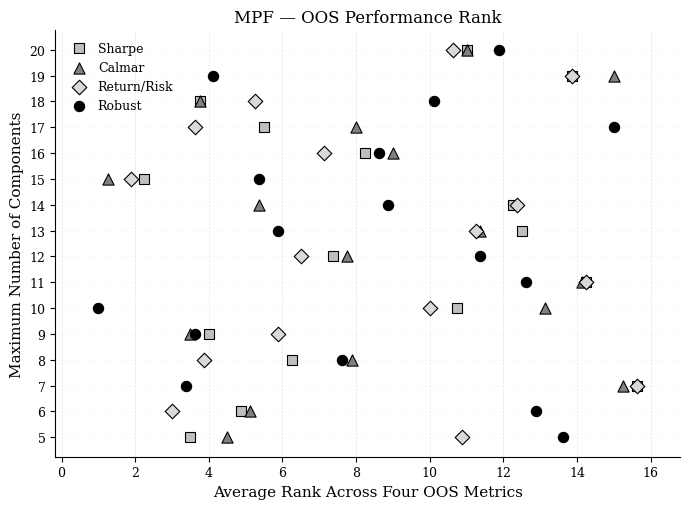


BEST COMPONENT COUNT FOR EACH SELECTION METHOD
Calmar         : 15 components (average rank = 1.25)
Return/Risk    : 15 components (average rank = 1.88)
Robust         : 10 components (average rank = 1.00)
Sharpe         : 15 components (average rank = 2.25)

OVERALL BEST COMPONENT COUNTS
                    Average Rank  Overall Rank
max_num_components                            
15                          2.69           1.0
9                           4.25           2.0
18                          5.72           3.0
8                           6.41           4.0
6                           6.47           5.0
17                          8.03           6.0
5                           8.12           7.0
12                          8.25           8.5
16                          8.25           8.5
10                          8.72          10.0
14                          9.72          11.0
13                         10.25          12.0
20                         11.12          13.0
19  

In [12]:
average_rank, overall_table = plot_mpf_rank_2d(df)

In [ ]:
# Define final candidates

candidate_1 = {
    "components": 11,
    "method": "Calmar",
    "return_column": "calmar_oos_return",
    "label": "MPF — 11 Components / Calmar"
}

candidate_2 = {
    "components": 18,
    "method": "Sharpe",
    "return_column": "sharpe_oos_return",
    "label": "MPF — 18 Components / Sharpe"
}

wealth_results = plot_mpf_oos_cumulative_wealth(
    df,
    candidate_1,
    candidate_2
)

In [14]:
# access the final values directly

print("\n" + "=" * 60)
print("OOS CUMULATIVE WEALTH")
print("=" * 60)

print(f"Candidate 1 final wealth:   {wealth_results['final_wealth_1']:,.2f}")
print(f"Candidate 2 final wealth:   {wealth_results['final_wealth_2']:,.2f}")
print(f"Benchmark final wealth:     {wealth_results['final_benchmark']:,.2f}")

print("-" * 60)

print(
    f"Candidate 1 outperformance:  "
    f"{wealth_results['relative_outperformance_1']:.2%}"
)

print(
    f"Candidate 2 outperformance:  "
    f"{wealth_results['relative_outperformance_2']:.2%}"
)

print("=" * 60)



OOS CUMULATIVE WEALTH
Candidate 1 final wealth:   345.26
Candidate 2 final wealth:   361.23
Benchmark final wealth:     211.25
------------------------------------------------------------
Candidate 1 outperformance:  63.43%
Candidate 2 outperformance:  70.99%


### Train INSTABILITY DEGRADATION RANKING

##### 500/100

In [ ]:
# Threshold stability: BUY/SELL thresholds across calibration windows.
# Train/OOS generalization: calibration return vs. OOS return, including degradation.
# OOS stability: OOS return and OOS excess return across the walk-forward windows.

In [12]:
import pandas as pd


def measure_threshold_stability(df):
    """
    Measure BUY/SELL threshold stability across calibration windows
    for each method and max_num_components.

    Returns one row per method × max_num_components.
    """

    methods = {
        "Sharpe": ("sharpe_buy_thr", "sharpe_sell_thr"),
        "Calmar": ("calmar_buy_thr", "calmar_sell_thr"),
        "Return/Risk": ("return_risk_buy_thr", "return_risk_sell_thr"),
        "Robust": ("robust_buy_thr", "robust_sell_thr"),
    }

    results = []

    for method, (buy_col, sell_col) in methods.items():

        for n_components, group in df.groupby("max_num_components"):

            group = group.sort_values("calibration_start").copy()

            buy = group[buy_col].dropna()
            sell = group[sell_col].dropna()

            # Threshold dispersion across calibration windows
            buy_sd = buy.std()
            sell_sd = sell.std()

            # Threshold changes from one calibration window to the next
            buy_change = buy.diff().abs().mean()
            sell_change = sell.diff().abs().mean()

            # Combined threshold movement
            threshold_change = (
                (buy.diff() ** 2 + sell.diff() ** 2) ** 0.5
            ).mean()

            results.append({
                "method": method,
                "max_num_components": n_components,
                "buy_thr_sd": buy_sd,
                "sell_thr_sd": sell_sd,
                "buy_thr_mean_abs_change": buy_change,
                "sell_thr_mean_abs_change": sell_change,
                "threshold_mean_change": threshold_change,
                "n_windows": len(group)
            })

    return pd.DataFrame(results)

In [13]:
# Threshold stability: BUY/SELL thresholds across calibration windows.
# Lower values = more stable threshold selection.

threshold_stability = measure_threshold_stability(df)

threshold_stability

,method,max_num_components,buy_thr_sd,sell_thr_sd,buy_thr_mean_abs_change,sell_thr_mean_abs_change,threshold_mean_change,n_windows
0,Sharpe,5,0.077800,0.062539,0.102500,0.073750,0.132598,9
1,Sharpe,6,0.077460,0.055678,0.101250,0.067500,0.124110,9
2,Sharpe,7,0.056960,0.082158,0.056250,0.068750,0.094846,9
3,Sharpe,8,0.033582,0.030185,0.043750,0.030000,0.056792,9
4,Sharpe,9,0.089969,0.074907,0.097500,0.076250,0.135496,9
...,...,...,...,...,...,...,...,...
59,Robust,16,0.011487,0.014601,0.005000,0.019375,0.021353,9
60,Robust,17,0.015833,0.011118,0.019375,0.007500,0.020941,9
61,Robust,18,0.045000,0.014672,0.063125,0.018125,0.067246,9
62,Robust,19,0.027170,0.014142,0.030000,0.010625,0.033778,9


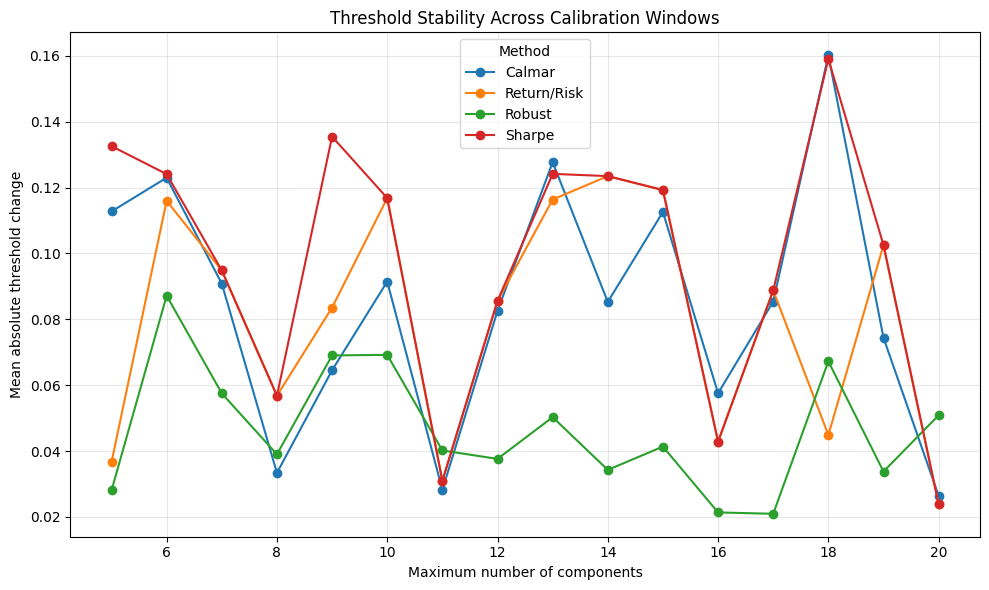

In [14]:
import matplotlib.pyplot as plt

plot_df = threshold_stability.pivot(
    index="max_num_components",
    columns="method",
    values="threshold_mean_change"
)

ax = plot_df.plot(
    marker="o",
    figsize=(10, 6)
)

ax.set_xlabel("Maximum number of components")
ax.set_ylabel("Mean absolute threshold change")
ax.set_title("Threshold Stability Across Calibration Windows")
ax.grid(True, alpha=0.3)

plt.legend(title="Method")
plt.tight_layout()
plt.show()

In [ ]:
# does Robust lose less performance when moving from calibration to OOS?

In [15]:
import pandas as pd


def measure_calibration_oos_stability(df):
    """
    Measure calibration -> OOS performance degradation
    for each method and max_num_components.
    """

    methods = {
        "Sharpe": (
            "sharpe_calibration_return",
            "sharpe_oos_return",
        ),
        "Calmar": (
            "calmar_calibration_return",
            "calmar_oos_return",
        ),
        "Return/Risk": (
            "return_risk_calibration_return",
            "return_risk_oos_return",
        ),
        "Robust": (
            "robust_calibration_return",
            "robust_oos_return",
        ),
    }

    results = []

    for method, (cal_col, oos_col) in methods.items():

        for n_components, group in df.groupby("max_num_components"):

            cal = group[cal_col]
            oos = group[oos_col]

            degradation = cal - oos

            # Relative performance retained from calibration to OOS
            retention = oos / cal.replace(0, pd.NA)

            results.append({
                "method": method,
                "max_num_components": n_components,

                "calibration_return_mean": cal.mean(),
                "calibration_return_sd": cal.std(),

                "oos_return_mean": oos.mean(),
                "oos_return_sd": oos.std(),

                "degradation_mean": degradation.mean(),
                "degradation_sd": degradation.std(),

                "retention_mean": retention.mean(),
                "retention_sd": retention.std(),

                "n_windows": len(group)
            })

    return pd.DataFrame(results)

In [ ]:
# Lower = less calibration-to-OOS deterioration and more stable generalization.
cal_oos_stability = measure_calibration_oos_stability(df)

cal_oos_stability

,method,max_num_components,calibration_return_mean,calibration_return_sd,oos_return_mean,oos_return_sd,degradation_mean,degradation_sd,retention_mean,retention_sd,n_windows
0,Sharpe,5,2.930140,1.210929,0.142327,0.119151,2.787813,1.181423,0.049139,0.057653,9
1,Sharpe,6,4.038443,1.472162,0.120473,0.173056,3.917970,1.450372,0.030872,0.038051,9
2,Sharpe,7,4.133133,1.551902,0.037623,0.144246,4.095510,1.514813,0.004070,0.044411,9
3,Sharpe,8,3.620919,1.279301,0.117241,0.097360,3.503678,1.268175,0.035865,0.037784,9
4,Sharpe,9,3.305535,0.728754,0.125276,0.205028,3.180259,0.823218,0.042638,0.058092,9
...,...,...,...,...,...,...,...,...,...,...,...
59,Robust,16,2.407941,0.910852,0.059663,0.142674,2.348278,0.884725,0.022602,0.070508,9
60,Robust,17,2.283068,0.651276,0.025652,0.125551,2.257416,0.705364,0.015761,0.060325,9
61,Robust,18,2.148525,0.618374,0.046436,0.150598,2.102088,0.655582,0.026323,0.073466,9
62,Robust,19,2.006192,0.752179,0.109917,0.171240,1.896275,0.803127,0.074564,0.118004,9


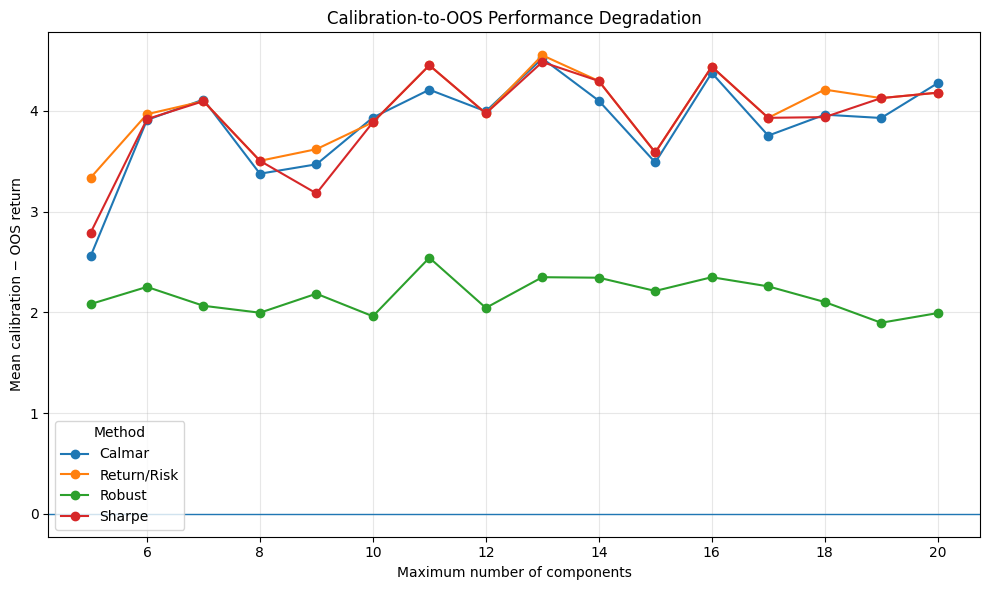

In [17]:
import matplotlib.pyplot as plt

plot_df = cal_oos_stability.pivot(
    index="max_num_components",
    columns="method",
    values="degradation_mean"
)

ax = plot_df.plot(
    marker="o",
    figsize=(10, 6)
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Maximum number of components")
ax.set_ylabel("Mean calibration − OOS return")
ax.set_title("Calibration-to-OOS Performance Degradation")
ax.grid(True, alpha=0.3)

plt.legend(title="Method")
plt.tight_layout()
plt.show()

In [ ]:
# OOS excess-return stability across the walk-forward windows,

In [18]:
def measure_oos_excess_stability(df):
    methods = {
        "Sharpe": "sharpe_excess_return",
        "Calmar": "calmar_excess_return",
        "Return/Risk": "return_risk_excess_return",
        "Robust": "robust_excess_return",
    }

    results = []

    for method, col in methods.items():
        for n_components, group in df.groupby("max_num_components"):

            excess = group[col].dropna()

            results.append({
                "method": method,
                "max_num_components": n_components,
                "oos_excess_mean": excess.mean(),
                "oos_excess_sd": excess.std(),
                "oos_excess_min": excess.min(),
                "positive_pct": (excess > 0).mean() * 100,
                "n_windows": len(excess),
            })

    return pd.DataFrame(results)

In [19]:
oos_excess_stability = measure_oos_excess_stability(df)
oos_excess_stability

,method,max_num_components,oos_excess_mean,oos_excess_sd,oos_excess_min,positive_pct,n_windows
0,Sharpe,5,0.048895,0.146963,-0.100623,44.444444,9
1,Sharpe,6,0.027041,0.155641,-0.134324,66.666667,9
2,Sharpe,7,-0.055810,0.177289,-0.423871,22.222222,9
3,Sharpe,8,0.023808,0.139796,-0.133524,55.555556,9
4,Sharpe,9,0.031844,0.170755,-0.134324,55.555556,9
...,...,...,...,...,...,...,...
59,Robust,16,-0.033770,0.170063,-0.397379,44.444444,9
60,Robust,17,-0.067781,0.143421,-0.403898,11.111111,9
61,Robust,18,-0.046996,0.116137,-0.245476,44.444444,9
62,Robust,19,0.016485,0.168347,-0.229851,44.444444,9


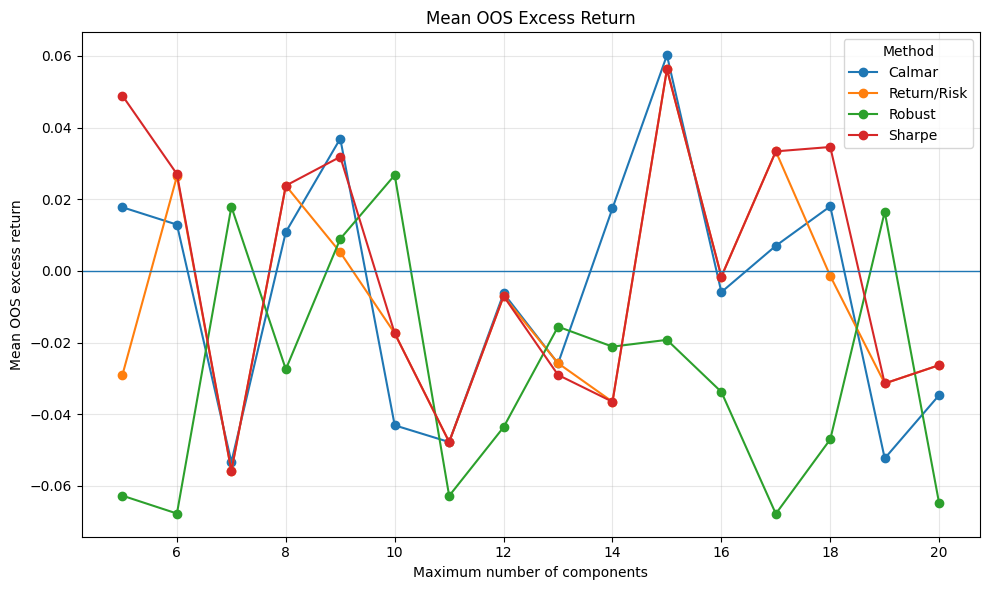

In [ ]:
# This is the key next test: does the Robust method's greater stability and lower degradation actually translate into higher OOS excess return?

import matplotlib.pyplot as plt

plot_df = oos_excess_stability.pivot(
    index="max_num_components",
    columns="method",
    values="oos_excess_mean"
)

ax = plot_df.plot(
    marker="o",
    figsize=(10, 6)
)

ax.axhline(0, linewidth=1)
ax.set_xlabel("Maximum number of components")
ax.set_ylabel("Mean OOS excess return")
ax.set_title("Mean OOS Excess Return")
ax.grid(True, alpha=0.3)

plt.legend(title="Method")
plt.tight_layout()
plt.show()

In [21]:
# Let's test whether Robust is more stable OOS, independent of whether its mean return is higher.
def compare_oos_stability(oos_excess_stability):
    return (
        oos_excess_stability[
            [
                "method",
                "max_num_components",
                "oos_excess_mean",
                "oos_excess_sd",
                "oos_excess_min",
                "positive_pct",
            ]
        ]
        .sort_values(["max_num_components", "method"])
        .reset_index(drop=True)
    )


oos_comparison = compare_oos_stability(oos_excess_stability)

print(oos_comparison.to_string(index=False))

     method  max_num_components  oos_excess_mean  oos_excess_sd  oos_excess_min  positive_pct
     Calmar                   5         0.017765       0.167504       -0.179144     44.444444
Return/Risk                   5        -0.028953       0.205085       -0.405261     44.444444
     Robust                   5        -0.062726       0.085593       -0.235588     22.222222
     Sharpe                   5         0.048895       0.146963       -0.100623     44.444444
     Calmar                   6         0.012925       0.157109       -0.134324     55.555556
Return/Risk                   6         0.026421       0.155527       -0.134324     66.666667
     Robust                   6        -0.067706       0.117473       -0.310856     44.444444
     Sharpe                   6         0.027041       0.155641       -0.134324     66.666667
     Calmar                   7        -0.053323       0.175868       -0.423871     22.222222
Return/Risk                   7        -0.055810       0.177

In [23]:
# compare Robust against the three single metrics
robust = oos_excess_stability[
    oos_excess_stability["method"] == "Robust"
].set_index("max_num_components")

single = oos_excess_stability[
    oos_excess_stability["method"] != "Robust"
]

comparison = single.copy()

comparison["robust_sd"] = comparison["max_num_components"].map(
    robust["oos_excess_sd"]
)

comparison["robust_min"] = comparison["max_num_components"].map(
    robust["oos_excess_min"]
)

comparison["robust_mean"] = comparison["max_num_components"].map(
    robust["oos_excess_mean"]
)

comparison["sd_difference"] = (
    comparison["oos_excess_sd"] - comparison["robust_sd"]
)

comparison["min_difference"] = (
    comparison["oos_excess_min"] - comparison["robust_min"]
)

print(
    comparison[
        [
            "method",
            "max_num_components",
            "oos_excess_sd",
            "robust_sd",
            "sd_difference",
            "oos_excess_min",
            "robust_min",
            "min_difference",
        ]
    ].to_string(index=False)
)

     method  max_num_components  oos_excess_sd  robust_sd  sd_difference  oos_excess_min  robust_min  min_difference
     Sharpe                   5       0.146963   0.085593       0.061370       -0.100623   -0.235588        0.134965
     Sharpe                   6       0.155641   0.117473       0.038168       -0.134324   -0.310856        0.176532
     Sharpe                   7       0.177289   0.099211       0.078078       -0.423871   -0.073586       -0.350285
     Sharpe                   8       0.139796   0.158424      -0.018629       -0.133524   -0.302921        0.169398
     Sharpe                   9       0.170755   0.157488       0.013267       -0.134324   -0.158739        0.024416
     Sharpe                  10       0.124885   0.102746       0.022139       -0.193284   -0.090946       -0.102338
     Sharpe                  11       0.159836   0.134496       0.025340       -0.390422   -0.310302       -0.080120
     Sharpe                  12       0.177594   0.085980       

In [25]:
# test whether threshold instability is associated with OOS excess-return instability.

def measure_threshold_oos_relationship(
    threshold_stability,
    oos_excess_stability
):
    """
    Measure the relationship between threshold instability
    and OOS excess-return instability.

    Lower threshold_mean_change = more stable thresholds.
    Lower oos_excess_sd = more stable OOS performance.
    """

    df_rel = threshold_stability[
        ["method", "max_num_components", "threshold_mean_change"]
    ].merge(
        oos_excess_stability[
            ["method", "max_num_components", "oos_excess_sd"]
        ],
        on=["method", "max_num_components"],
        how="inner"
    )

    results = []

    for method, group in df_rel.groupby("method"):

        pearson = group["threshold_mean_change"].corr(
            group["oos_excess_sd"],
            method="pearson"
        )

        spearman = group["threshold_mean_change"].corr(
            group["oos_excess_sd"],
            method="spearman"
        )

        results.append({
            "method": method,
            "pearson_corr": pearson,
            "spearman_corr": spearman,
            "n_components": len(group)
        })

    return pd.DataFrame(results), df_rel

In [26]:
relationship_results, relationship_df = (
    measure_threshold_oos_relationship(
        threshold_stability,
        oos_excess_stability
    )
)

relationship_results

,method,pearson_corr,spearman_corr,n_components
0,Calmar,0.076853,0.082353,16
1,Return/Risk,-0.421542,-0.364706,16
2,Robust,-0.141052,-0.011765,16
3,Sharpe,-0.164551,-0.167647,16


In [ ]:
# What we want to see

# The hypothesis predicts:

# higher threshold instability → higher OOS instability

# so we would expect positive Pearson/Spearman correlations.

# Most importantly, we want to see whether Robust consistently occupies the lower-left region: stable thresholds and stable OOS excess returns.

# With only 16 component values (5–20), treat the correlations as exploratory evidence, not statistical proof.

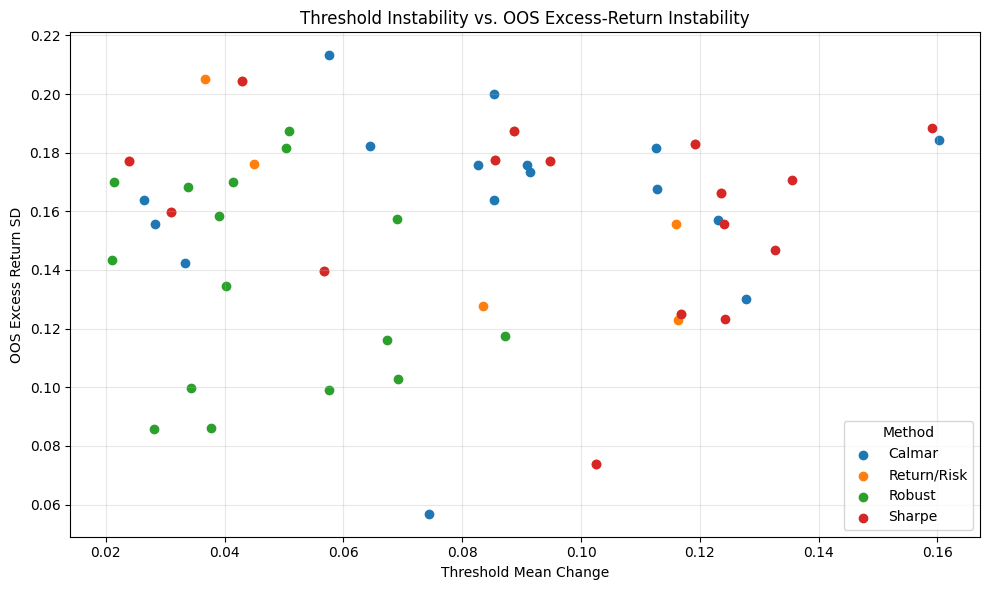

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for method, group in relationship_df.groupby("method"):
    ax.scatter(
        group["threshold_mean_change"],
        group["oos_excess_sd"],
        label=method
    )

ax.set_xlabel("Threshold Mean Change")
ax.set_ylabel("OOS Excess Return SD")
ax.set_title(
    "Threshold Instability vs. OOS Excess-Return Instability"
)

ax.grid(True, alpha=0.3)
ax.legend(title="Method")

plt.tight_layout()
plt.show()

In [28]:
# How often does each method achieve simultaneously low threshold instability AND low OOS instability?

def measure_lower_left_concentration(
    threshold_stability,
    oos_excess_stability
):
    df = threshold_stability[
        ["method", "max_num_components", "threshold_mean_change"]
    ].merge(
        oos_excess_stability[
            ["method", "max_num_components", "oos_excess_sd"]
        ],
        on=["method", "max_num_components"]
    )

    # Common thresholds across all methods
    x_thr = df["threshold_mean_change"].median()
    y_thr = df["oos_excess_sd"].median()

    df["stable_threshold"] = (
        df["threshold_mean_change"] <= x_thr
    )

    df["stable_oos"] = (
        df["oos_excess_sd"] <= y_thr
    )

    df["lower_left"] = (
        df["stable_threshold"] &
        df["stable_oos"]
    )

    results = (
        df.groupby("method")
        .agg(
            n_components=("max_num_components", "count"),
            lower_left_count=("lower_left", "sum"),
            lower_left_pct=("lower_left", "mean"),
            stable_threshold_pct=("stable_threshold", "mean"),
            stable_oos_pct=("stable_oos", "mean")
        )
        .reset_index()
    )

    return results, df, x_thr, y_thr

In [ ]:
# Robust optimization more frequently produces parameter configurations that are simultaneously stable across calibration windows and stable in OOS performance.

# That is stronger and more relevant than the correlation test.

lower_left_results, lower_left_df, x_thr, y_thr = (
    measure_lower_left_concentration(
        threshold_stability,
        oos_excess_stability
    )
)

print("Threshold stability median:", x_thr)
print("OOS stability median:", y_thr)

lower_left_results

Threshold stability median: 0.08307016036031431
OOS stability median: 0.1651577630417847


,method,n_components,lower_left_count,lower_left_pct,stable_threshold_pct,stable_oos_pct
0,Calmar,16,4,0.250,0.4375,0.4375
1,Return/Risk,16,2,0.125,0.3750,0.4375
2,Robust,16,10,0.625,0.9375,0.6875
3,Sharpe,16,2,0.125,0.2500,0.4375


Maybe to use the last metric as the final selection metric? The challenge is not to select the method after the classical performance measurments, as we can easily be misleaded by very high local optima, which do have great train metrics even on OOS, but than pure one during the final test phase. In order to demonstrate this effect this article will show at the end what the real test performance is based on the best single metrics and the robust approach. 

Maybe this metric and plot can be performed on combined train results from different N_MC2[100, 250, 500, 1000] and random_seeds... This will demonstrate that more stability is generated only true robust. In contrary if we would use our old ranking method to select the best metrics, max_n_components we will end up in week test results.

### Test

#### 500/500

#### 500/2000

#### 2000/2000

## Momentum